<a href="https://colab.research.google.com/github/KRamBalaji/Water-Quality-Classification-Public-Health-Analytics-EDA-ML-/blob/main/Water_Quality_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Water Quality Classification & Public Health Analytics**

## **Problem Statement**
The Maharashtra Pollution Control Board (MPCB) and the National Water Monitoring Programme (NWMP) collect extensive environmental data to monitor the health of water bodies across the state. However, raw physicochemical and biological data is complex and difficult for public health officials to interpret immediately.

The core challenge of this project is to develop a robust multiclass classification model that can automatically categorize water bodies into four distinct quality classes (A, B, C, or E) based on variables such as pH, Dissolved Oxygen (DO), and Bacterial counts.

**Key Objectives**

*  **Automated Classification:** Build a machine learning model to replace manual assessment with a data-driven approach to identify if water is fit for drinking, bathing, or industrial use.
*  **Public Health Analytics:** Identify the primary drivers of water pollution (e.g., high BOD or fecal coliform) to provide actionable insights for health interventions.
* **Predictive Accuracy:** Navigate significant data challenges, including real-world missing values and class imbalances (where "Class A" data is far more prevalent than "Class B" or "C"), to ensure reliable predictions.

By successfully classifying these water bodies, this project aims to provide a scalable tool that can inform water treatment strategies and protect public health across Maharashtra.

## **Exploratory Data Analysis(EDA)**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# 1. Load the Dataset
file_path = '/content/drive/My Drive/NWMP_August2025_MPCB_0.csv'
df = pd.read_csv(file_path, encoding_errors='ignore')

In [19]:
# 2. Target Simplification (Map descriptions to Classes A, B, C, E)
class_mapping = {
    'A (Drinking Water source without conventional treatment but after disinfection)': 'A',
    'B (Outdoor bathing(Organized))': 'B',
    'C (Drinking water source)': 'C',
    'E (Irrigation, industrial cooling and controlled waste)': 'E'
}
df['Target_Class'] = df['Use Based Class'].map(class_mapping)

In [20]:
# 3. Numeric Data Cleaning (Handle '(BDL)' and non-numeric characters)
def to_numeric(val):
    if pd.isna(val): return np.nan
    if isinstance(val, (int, float)): return float(val)
    # Remove '(BDL)' and extra whitespace
    cleaned = re.sub(r'\(BDL\)', '', str(val)).strip()
    try:
        return float(cleaned)
    except ValueError:
        return np.nan

In [21]:
# Define key features for analysis as per project brief
numeric_cols = [
    'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N',
    'Fecal Coliform', 'Total Coliform', 'Turbidity', 'Temperature',
    'COD', 'Total Dissolved Solids'
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].apply(to_numeric)

# Filter for labeled data only for EDA
eda_df = df[df['Target_Class'].notnull()].copy()

/tmp/ipython-input-3798053866.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x='Target_Class', order=['A', 'B', 'C', 'E'], palette='viridis')


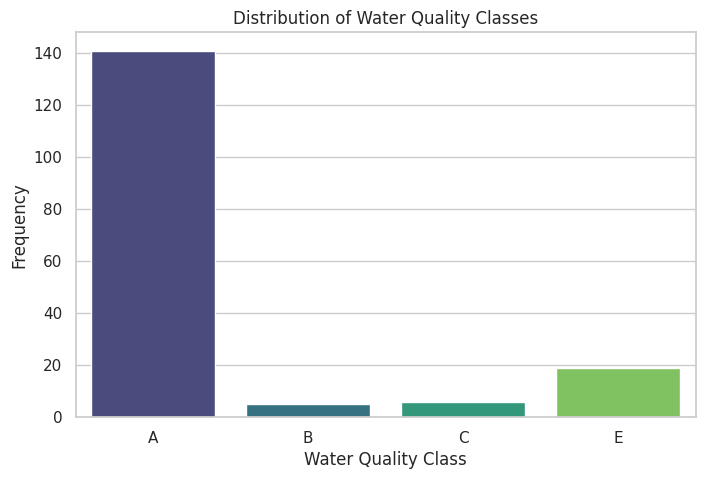

In [22]:
# --- VISUALIZATIONS ---

# Visualization 1: Class Distribution (Identify Class Imbalance)
plt.figure(figsize=(8, 5))
sns.countplot(data=eda_df, x='Target_Class', order=['A', 'B', 'C', 'E'], palette='viridis')
plt.title('Distribution of Water Quality Classes')
plt.xlabel('Water Quality Class')
plt.ylabel('Frequency')
plt.show()

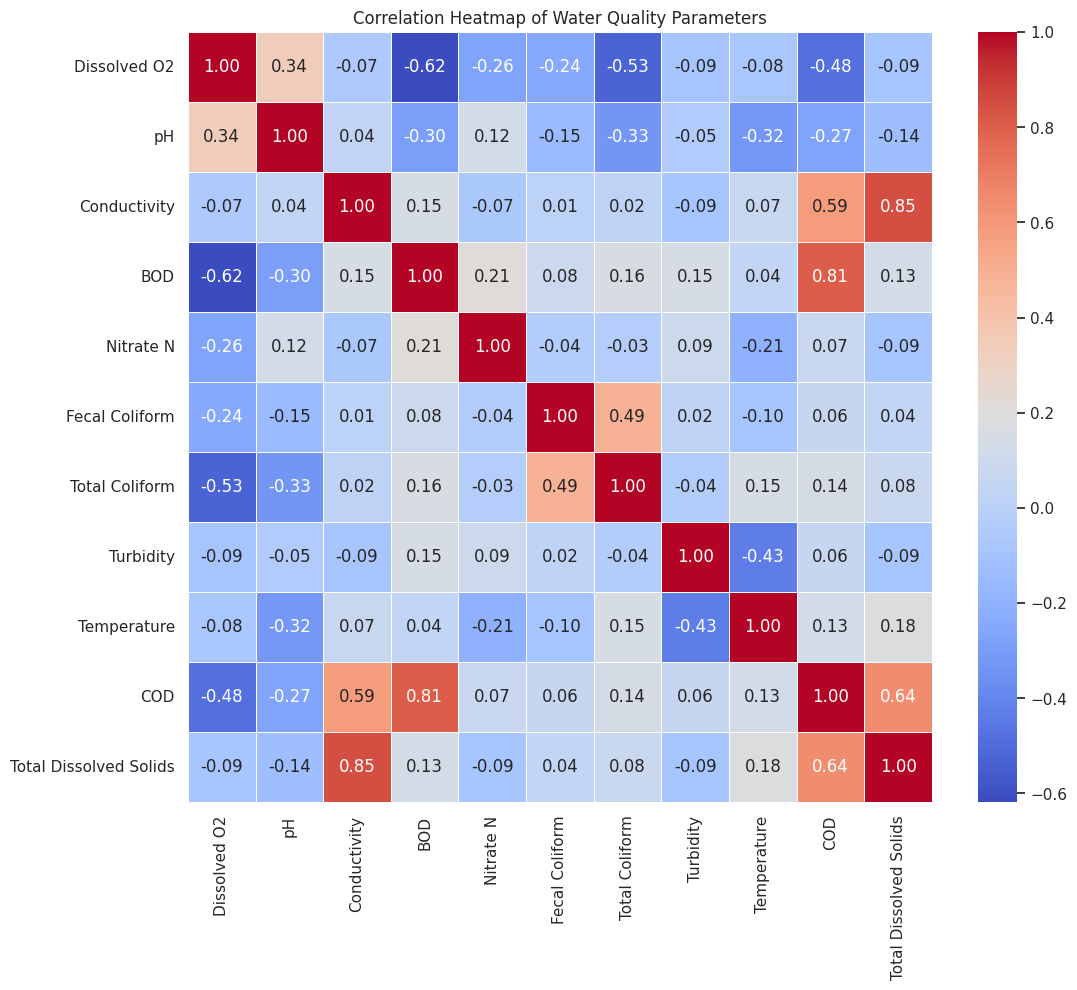

In [23]:
# Visualization 2: Correlation Heatmap (Identify redundant features)
plt.figure(figsize=(12, 10))
corr = eda_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Water Quality Parameters')
plt.show()

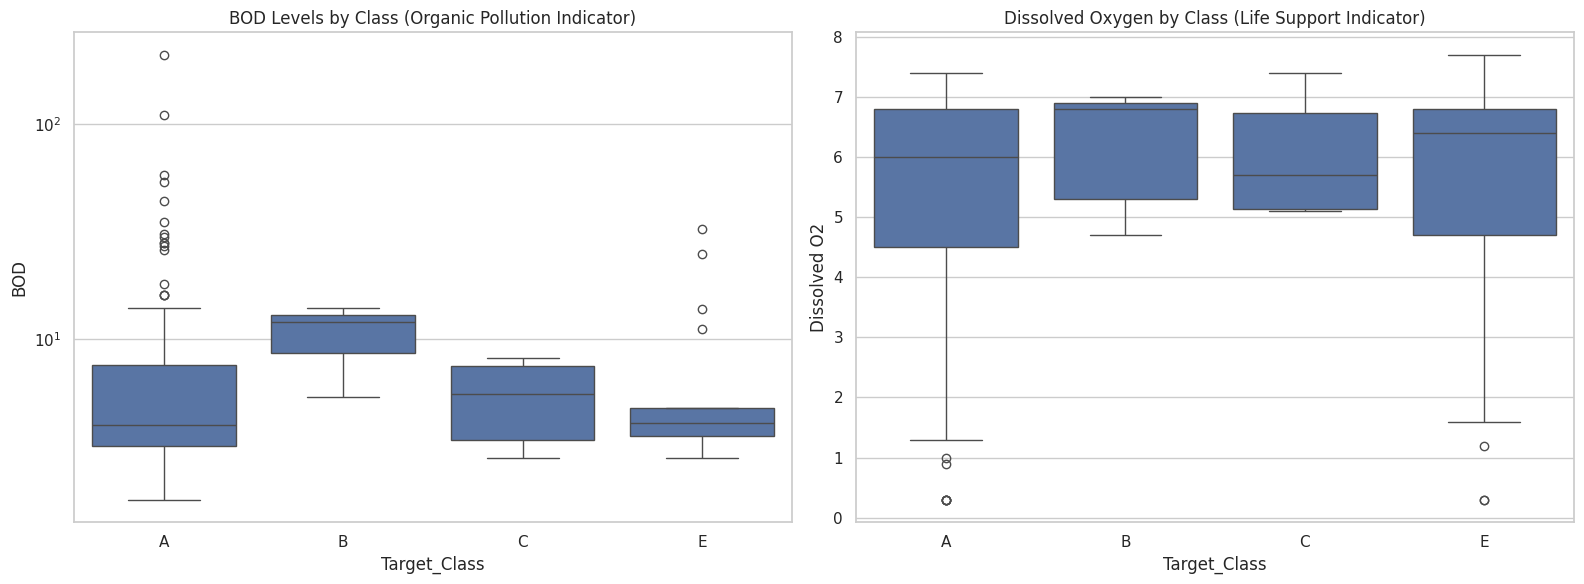

In [24]:
# Visualization 3: Boxplots for Key Pollutants (BOD and DO)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use log scale for BOD due to high variance
sns.boxplot(ax=axes[0], data=eda_df, x='Target_Class', y='BOD', order=['A', 'B', 'C', 'E'])
axes[0].set_title('BOD Levels by Class (Organic Pollution Indicator)')
axes[0].set_yscale('log')

sns.boxplot(ax=axes[1], data=eda_df, x='Target_Class', y='Dissolved O2', order=['A', 'B', 'C', 'E'])
axes[1].set_title('Dissolved Oxygen by Class (Life Support Indicator)')

plt.tight_layout()
plt.show()

In [25]:
# --- STATISTICAL SUMMARY ---
print("--- Statistical Summary of Key Parameters ---")
print(eda_df[numeric_cols].describe())

print("\n--- Target Class Counts ---")
print(eda_df['Target_Class'].value_counts())

--- Statistical Summary of Key Parameters ---
       Dissolved O2          pH  Conductivity         BOD   Nitrate N  \
count    171.000000  171.000000    171.000000  171.000000  169.000000   
mean       5.533333    7.908772   3695.333333    9.343860    1.411065   
std        1.781473    0.465750  10126.151358   19.394259    1.844571   
min        0.300000    6.900000     45.000000    1.800000    0.300000   
25%        4.650000    7.500000    230.500000    3.200000    0.540000   
50%        6.100000    7.900000    467.000000    4.000000    0.850000   
75%        6.850000    8.300000    813.000000    8.000000    1.840000   
max        7.700000    9.700000  74240.000000  210.000000   21.000000   

       Fecal Coliform  Total Coliform   Turbidity  Temperature         COD  \
count      171.000000      171.000000  171.000000   149.000000  171.000000   
mean        81.451462      388.457895    8.042924    25.865772   43.535088   
std        183.389069      422.770699   18.352066     3.257336

## **Preprocessing & Modeling**

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle

# Drop rows without labels for modeling
data = df[df['Target_Class'].notnull()].copy()

# 2. DATA CLEANING & FEATURE SELECTION
# Defining the features that drive water quality classification
features = [
    'Dissolved O2', 'pH', 'Conductivity', 'BOD', 'Nitrate N',
    'Fecal Coliform', 'Total Coliform', 'Turbidity', 'Temperature',
    'COD', 'Total Dissolved Solids'
]

def clean_value(val):
    if pd.isna(val) or str(val).strip() in ['#N/A', 'NA', '']: return np.nan
    # Remove strings like '(BDL)', '>', '<'
    cleaned = re.sub(r'\(BDL\)|>|<', '', str(val)).strip()
    try: return float(cleaned)
    except: return np.nan

for col in features:
    data[col] = data[col].apply(clean_value)

In [42]:
# 3. FEATURE ENGINEERING: Organic Pollution Index (OPI)
# Creating a derived feature: Ratio of COD to BOD
data['COD_BOD_Ratio'] = data['COD'] / (data['BOD'] + 0.1)
features.append('COD_BOD_Ratio')

In [43]:
# 4. PREPROCESSING PIPELINE
X = data[features]
y = data['Target_Class'].astype(str)

# Handle Missing Values: Median Imputation
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# Feature Scaling: Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Label Encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [44]:
# 5. STRATIFIED TRAIN-TEST SPLIT
# Crucial to maintain class proportions for B, C, and E classes
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [48]:
# 6. TRAIN MULTIPLE MODELS
# Model 1: Logistic Regression (Balanced weights to handle imbalance)
lr_model = LogisticRegression(max_iter=2000, class_weight='balanced')
lr_model.fit(X_train, y_train)

# Model 2: Random Forest (Ensemble method)
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [50]:
# 7. EVALUATION WITH PER-CLASS METRICS
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    print(f"\n{'='*20} {name} {'='*20}")
    print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Ensuring labels are strings for the report formatting
    target_names = [str(c) for c in le.classes_]
    print("\nDetailed Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

evaluate_model(lr_model, X_test, y_test, "Logistic Regression")
evaluate_model(rf_model, X_test, y_test, "Random Forest")


==================== Logistic Regression ====================
Overall Accuracy: 0.5429

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.94      0.52      0.67        29
           B       0.50      1.00      0.67         1
           C       0.00      0.00      0.00         1
           E       0.60      0.75      0.67         4

    accuracy                           0.54        35
   macro avg       0.51      0.57      0.50        35
weighted avg       0.86      0.54      0.65        35

Confusion Matrix:
[[15  1 12  1]
 [ 0  1  0  0]
 [ 0  0  0  1]
 [ 1  0  0  3]]

==================== Random Forest ====================
Overall Accuracy: 0.8571

Detailed Classification Report:
              precision    recall  f1-score   support

           A       0.85      1.00      0.92        29
           B       1.00      1.00      1.00         1
           C       0.00      0.00      0.00         1
           E       0.00      0.00

In [47]:
# 8. SAVE OBJECTS FOR DEPLOYMENT
with open('logistic_regression.pkl', 'wb') as f: pickle.dump(lr_model, f)
with open('random_forest.pkl', 'wb') as f: pickle.dump(rf_model, f)
with open('scaler.pkl', 'wb') as f: pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f: pickle.dump(le, f)
with open('imputer.pkl', 'wb') as f: pickle.dump(imputer, f)

print("\nPhase 2 Complete: Models and Preprocessing tools saved.")


Phase 2 Complete: Models and Preprocessing tools saved.
